In [3]:
!pip install torch torchvision torchaudio


In [5]:
!pip install timm


     ---------------------------------------- 0.0/52.0 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.0 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.0 kB 165.2 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.0 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 52.0/52.0 kB 267.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.4 MB 2.6 MB/s eta 0:00:01
   --- ------------------------------------ 0.2/2.4 MB 2.9 MB/s eta 0:00:01
   --------- ------------------------------ 0.5/2.4 MB 4.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.6/2.4 MB 3.9 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.4 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.1/2.4 MB 4.2 MB/s eta 0:00:01
   ------------------------- -------------- 1.5/2.4 MB 4.7 MB/s eta 0:00:01
   -----------

In [3]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [4]:
# Update this path to where your dataset is stored
data_dir = "C:/Users/Balakumar/Downloads/archive (27)"  # Example: "C:/Users/yourname/bird_dataset"

image_size = 224
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_set = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
test_set = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size)

class_names = train_set.classes
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Found {num_classes} classes. Using device: {device}")


Found 200 classes. Using device: cpu


In [5]:
def train_model(model, criterion, optimizer, epochs=3):
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {running_loss / len(train_loader):.4f}")

def evaluate_model(model, dataloader):
    model.to(device)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1, y_true, y_pred


In [6]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names[:10], yticklabels=class_names[:10])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [7]:
#custom cnn
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * (image_size // 4) * (image_size // 4), 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.net(x)

model1 = SimpleCNN(num_classes)
train_model(model1, nn.CrossEntropyLoss(), torch.optim.Adam(model1.parameters()), epochs=3)
acc1, f1_1, _, _ = evaluate_model(model1, test_loader)


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [21:30<00:00,  4.37s/it]


Epoch 1 Loss: 5.5273


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [20:38<00:00,  4.20s/it]


Epoch 2 Loss: 5.2874


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [31:58<00:00,  6.50s/it]


Epoch 3 Loss: 5.1639


In [8]:
print(device)  # Should say 'cuda' if you're using a GPU


cpu


In [9]:
#resnet18
model2 = models.resnet18(pretrained=True)
model2.fc = nn.Linear(model2.fc.in_features, num_classes)
train_model(model2, nn.CrossEntropyLoss(), torch.optim.Adam(model2.parameters()), epochs=3)
acc2, f1_2, _, _ = evaluate_model(model2, test_loader)


C:\Users\Balakumar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Balakumar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [26:44<00:00,  5.44s/it]


Epoch 1 Loss: 4.1646


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [24:38<00:00,  5.01s/it]


Epoch 2 Loss: 2.5674


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [24:25<00:00,  4.97s/it]


Epoch 3 Loss: 1.7603


In [10]:
# EfficientNet-B0
model3 = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
train_model(model3, nn.CrossEntropyLoss(), torch.optim.Adam(model3.parameters()), epochs=3)
acc3, f1_3, y_t, y_p = evaluate_model(model3, test_loader)
P

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [36:19<00:00,  7.39s/it]


Epoch 1 Loss: 2.6447


Epoch 2: 100%|█████████████████████████████████████████████████████████████████████| 295/295 [4:07:22<00:00, 50.31s/it]


Epoch 2 Loss: 1.0195


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████| 295/295 [37:44<00:00,  7.68s/it]


Epoch 3 Loss: 0.5703


NameError: name 'P' is not defined

In [11]:
results = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet18", "EfficientNet-B0"],
    "Accuracy": [acc1, acc2,acc3],
    "F1 Score": [f1_1, f1_2, f1_3]
})
print(results)


             Model  Accuracy  F1 Score
0       Custom CNN  0.015164  0.004674
1         ResNet18  0.395535  0.377443
2  EfficientNet-B0  0.678180  0.667300


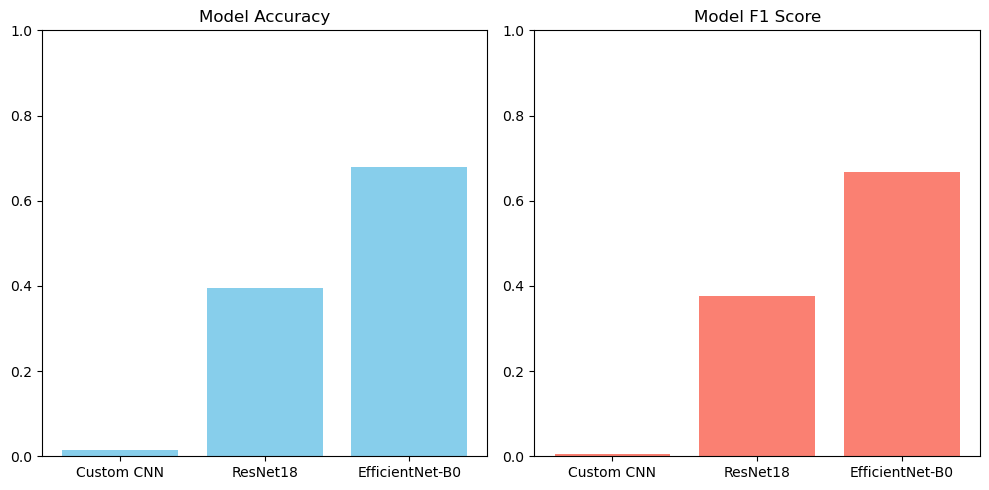

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(results["Model"], results["Accuracy"], color="skyblue")
plt.title("Model Accuracy")
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(results["Model"], results["F1 Score"], color="salmon")
plt.title("Model F1 Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


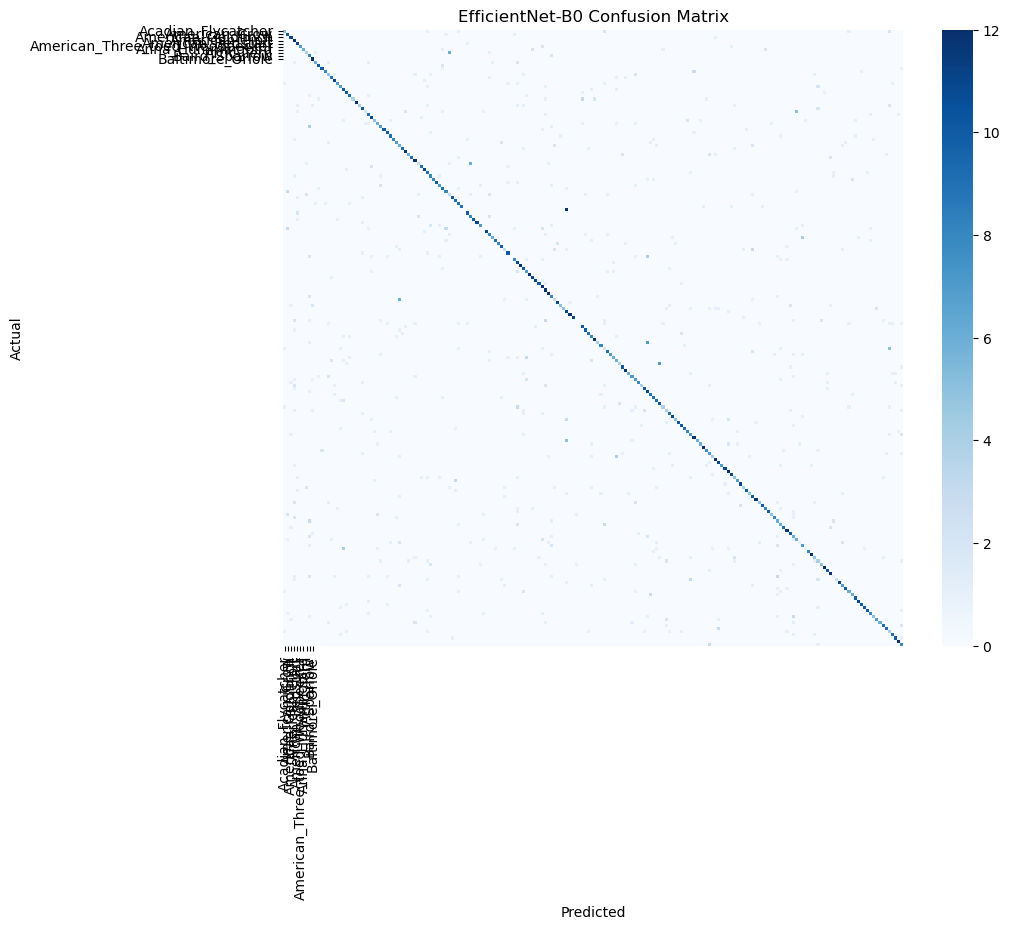

In [13]:
plot_cm(y_t, y_p, title="EfficientNet-B0 Confusion Matrix")

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming `results` is already available from the previous script
results = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet18", "EfficientNet-B0"],
    "Accuracy": [acc1, acc2, acc3],
    "F1 Score": [f1_1, f1_2, f1_3]
})

# Normalize scores for radar plot
normalized = results.copy()
normalized[["Accuracy", "F1 Score"]] = normalized[["Accuracy", "F1 Score"]] / normalized[["Accuracy", "F1 Score"]].max()

# 1. Grouped Bar Plot (Accuracy vs F1 Score)
x = np.arange(len(results["Model"]))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, results["Accuracy"], width, label='Accuracy', color='dodgerblue')
plt.bar(x + width/2, results["F1 Score"], width, label='F1 Score', color='orange')
plt.xticks(x, results["Model"])
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 2. Line Plot
plt.figure(figsize=(10,6))
plt.plot(results["Model"], results["Accuracy"], marker='o', label="Accuracy", color='green')
plt.plot(results["Model"], results["F1 Score"], marker='s', label="F1 Score", color='red')
plt.title("Line Plot of Accuracy and F1 Scores")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Radar Plot
labels = ["Accuracy", "F1 Score"]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

for i, row in normalized.iterrows():
    values = row[["Accuracy", "F1 Score"]].tolist()
    values += values[:1]
    ax.plot(ang)
            
            es, values, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_title("Normalized Radar Chart")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

# 4. Horizontal Bar Chart
results_sorted = results.sort_values("Accuracy", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(results_sorted["Model"], results_sorted["Accuracy"], color='skyblue', label='Accuracy')
plt.barh(results_sorted["Model"], results_sorted["F1 Score"], left=results_sorted["Accuracy"], color='lightcoral', label='F1 Score')
plt.xlabel("Score")
plt.title("Stacked Horizontal Bar Chart")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Table View
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('tight')
ax.axis('off')
table_data = results.round(4).values.tolist()
table = ax.table(cellText=table_data, colLabels=results.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title("Performance Summary Table")
plt.show()


IndentationError: unexpected indent (2423193905.py, line 57)